In [1]:
from MHW_daily_calcs import *

import matplotlib.pyplot as plt
import matplotlib.colors as mcol
import cmocean

In [2]:
climyrs=[1993,2022]
halfwin=10
qtile=.9
L=5 # 5 days
smoothClim=True
smoothmethod='tri'
meth=smoothmethod
win=halfwin
smoothedClim=smoothClim
ilead=0
window=win
delt=15
smoothedTrend=True
detr=True
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True) 
jj=120 # Arctic
qtvar='qt1'
delt=15

In [3]:
flist=[fnameOISSTAnom([ylimlistobs[0][0],ylimlistobs[-1][-1]],climyrs, jj, smoothClim, meth, win,L,detrended=True) for jj in range(0,180,60)]

In [4]:
ff=xr.open_mfdataset(flist,parallel=True,decode_times=True) 
ff=ff.where((ff.time>=cftime.DatetimeNoLeap(climyrs[0],1,1))&(ff.time<cftime.DatetimeNoLeap(climyrs[-1]+1,1,1)),drop=True)

In [5]:
flistq=[fnameOISSTQTile(climyrs, jj, qtile, smoothClim, meth, win,detr,delt,L) for jj in range(0,180,60)]
fQ=xr.open_mfdataset(flistq,parallel=True,decode_times=True)
fQ

<xarray.Dataset> Size: 38MB
Dimensions:  (yd: 73, lat: 180, lon: 360)
Coordinates:
  * yd       (yd) int64 584B 3 8 13 18 23 28 33 ... 333 338 343 348 353 358 363
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    qt1      (yd, lat, lon) float64 38MB dask.array<chunksize=(73, 60, 360), meta=np.ndarray>

In [6]:
flistM=[fnameOISSTMHW(climyrs, jj, qtile, smoothClim, meth, win,detr,delt,qtvar,L) for jj in range(0,180,60)]
fMHW=xr.open_mfdataset(flistM,parallel=True,decode_times=True)
fMHW=fMHW.where((ff.time>=cftime.DatetimeNoLeap(climyrs[0],1,1))&(ff.time<cftime.DatetimeNoLeap(climyrs[-1]+1,1,1)),drop=True)

In [13]:
def fnameCanESMAnomQtile(mdir, climyfirst, climylast, ilead, istartlat, qt, detrend=False, smoothClim=False,smoothTrend=False,meth=None,win=1,delt=0,L=1):
    if detrend:
        subdir='byLeadDetr.aside' if (smoothClim or smoothTrend) else 'byLeadDetrIndiv2'
    else:
        subdir='byLead' if (smoothClim or smoothTrend) else 'byLeadIndiv2'
    strSClim=f'_ClimS{meth}{win}' if smoothClim else ''
    strSTrend=f'_TrS{meth}{win}' if smoothClim else ''
    strdelt=f'_delt{delt}' # reflects number of lead time days to pool together
    qstr='{:.2f}'.format(qt).replace('.','_')
    detrstr=f"Detr" if detrend else ""
    climylast=2023
    return f"/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/byLeadDetr.aside/qtile{detrstr}ByLead{strSClim}{strSTrend}_cwao_CanESM5.1p1bc-v20240611_hindcast_C{climyfirst:04}_{climylast:04}_"\
            f"L{ilead:03}{strdelt}_j{istartlat:03}_q{qstr}_ocean_{L}d_surface_tso.nc"
jj=120
fmqlist=[fnameCanESMAnomQtile(workdir[L], climyrs[0], climyrs[-1], ilead, jj, qtile,detr,smoothClim=smoothedClim,
                                smoothTrend=smoothedTrend,meth=smoothmethod,win=window,delt=delt,L=L) for ilead in range(0,10)]
fmq=xr.open_mfdataset(fmqlist,parallel=True,decode_times=False,combine='nested',concat_dim='leadtime')
fmq

<xarray.Dataset> Size: 21MB
Dimensions:  (leadtime: 10, month: 12, lat: 60, lon: 360)
Coordinates:
  * month    (month) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * lat      (lat) float64 480B 30.5 31.5 32.5 33.5 34.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: leadtime
Data variables:
    qt1      (leadtime, month, lat, lon) float64 21MB dask.array<chunksize=(1, 12, 60, 360), meta=np.ndarray>

In [ ]:
fqm

In [14]:
ff

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 2190, lat: 180, lon: 360)
Coordinates:
  * time     (time) object 18kB 1993-01-03 12:00:00 ... 2022-12-29 12:00:00
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    sst_an   (time, lat, lon) float64 1GB dask.array<chunksize=(2190, 60, 360), meta=np.ndarray>

Richaud et al, 2024:
While some Arctic studies add an absolute, summer‐based value threshold condition to circumvent that issue (e.g., Huang, Wang, et al., 2021), we rather filter MHWs based on their intensity. More specifically, an Arctic MHW has a mean intensity relative to the climatological mean that exceeds a chosen value of 0.1°C. The number of detected MHWs is not very sensitive to the intensity threshold value, especially in summer. A lower value would include more winter, small amplitude MHWs that we aim to discard, while a higher value would eliminate some of the shoulder seasons and summer MHWs, that could be considered as relevant (Figure S1 in Supporting Information S1). The importance and processes related to the winter MHWs are discussed later (Section 4).

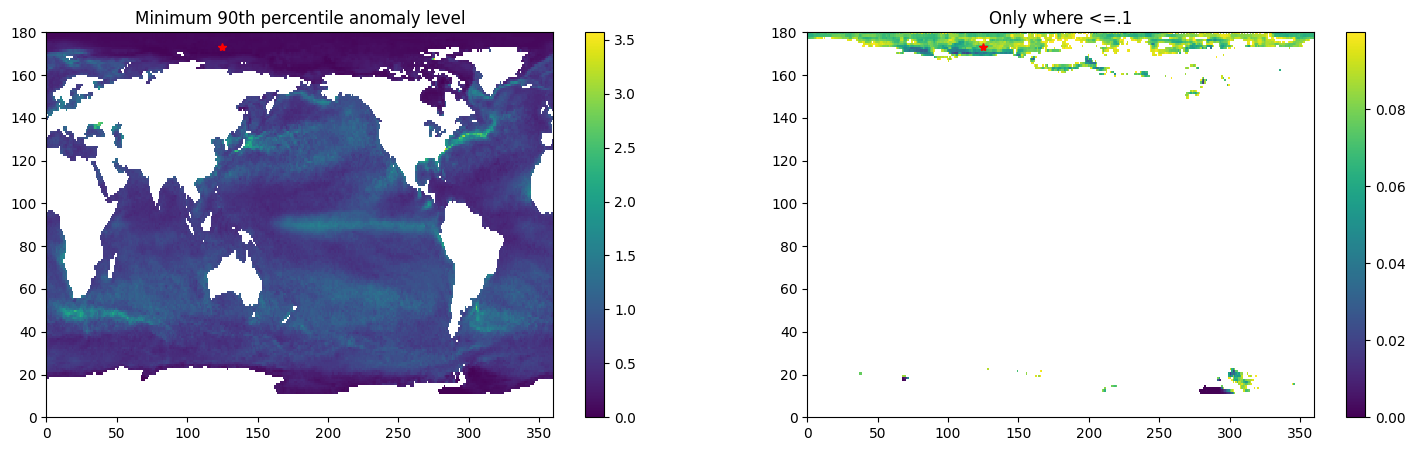

In [19]:
fig,ax=plt.subplots(1,2,figsize=(18,5))
y=fQ.qt1.min('yd')
m=ax[0].pcolormesh(y)
fig.colorbar(m,ax=ax[0])
ilon=125; ilat=173
ax[0].plot(ilon,ilat,'r*')
ax[0].set_title('Minimum 90th percentile anomaly level')
m=ax[1].pcolormesh(np.ma.masked_where(y>.1,y))
fig.colorbar(m,ax=ax[1])
ax[1].set_title('Only where <=.1')
ax[1].plot(ilon,ilat,'r*')

In [40]:
leads=(fmq.leadtime.values+.5)*5
test=fmq.isel(leadtime=0)
ilead=leads[0]
ts=np.array([yd365(cftime.DatetimeNoLeap(2021,mm,1)+dt.timedelta(days=ilead )) for mm in range(1,13)])
ts

array([  3,  34,  62,  93, 123, 154, 184, 215, 246, 276, 307, 337])

In [30]:
ilead

np.float64(2.5)

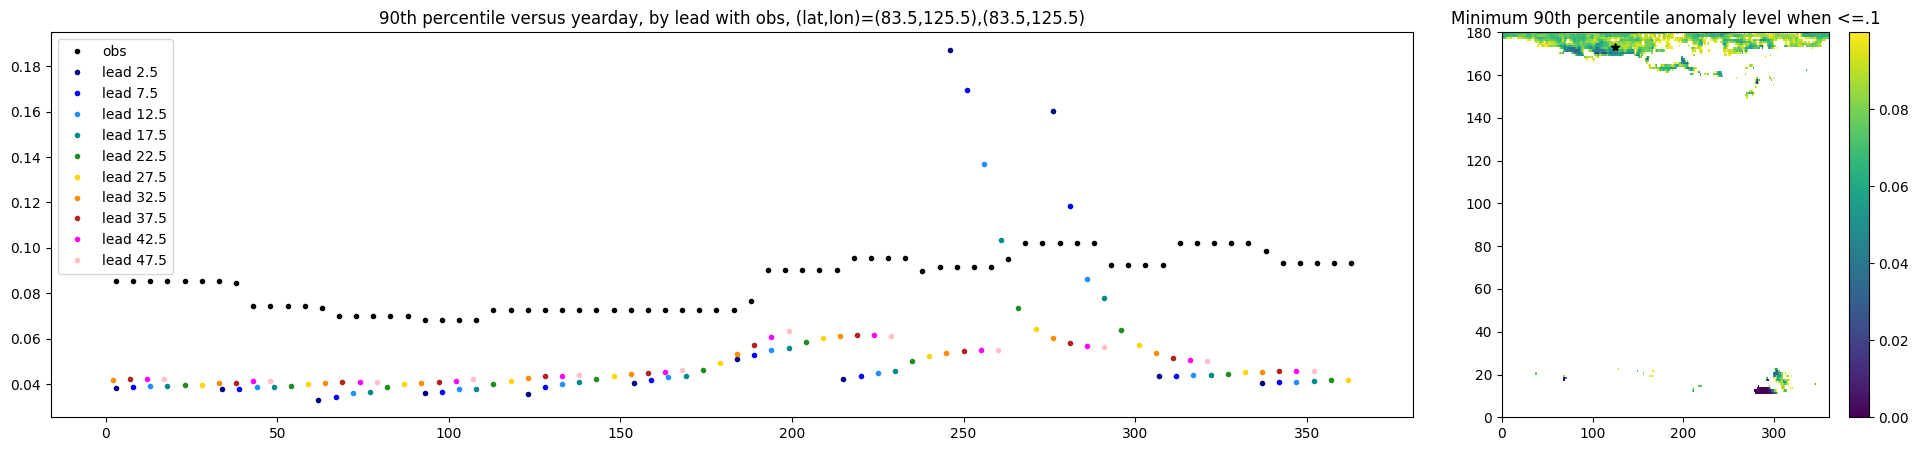

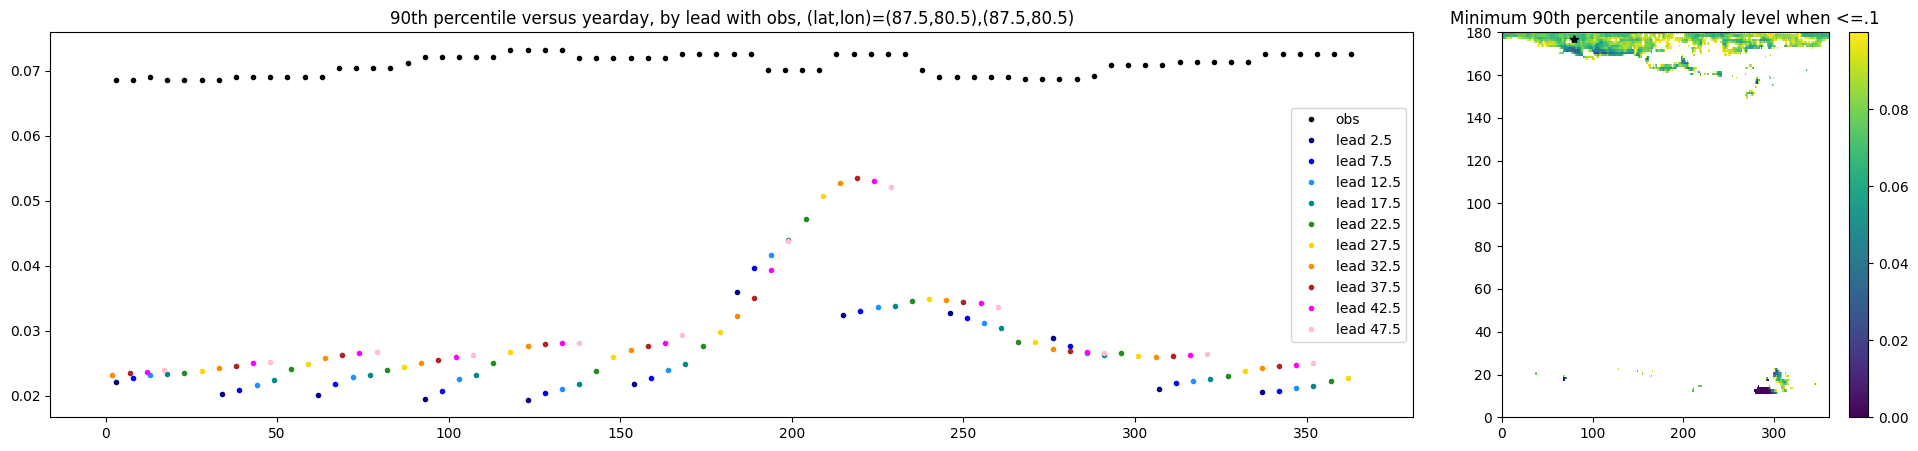

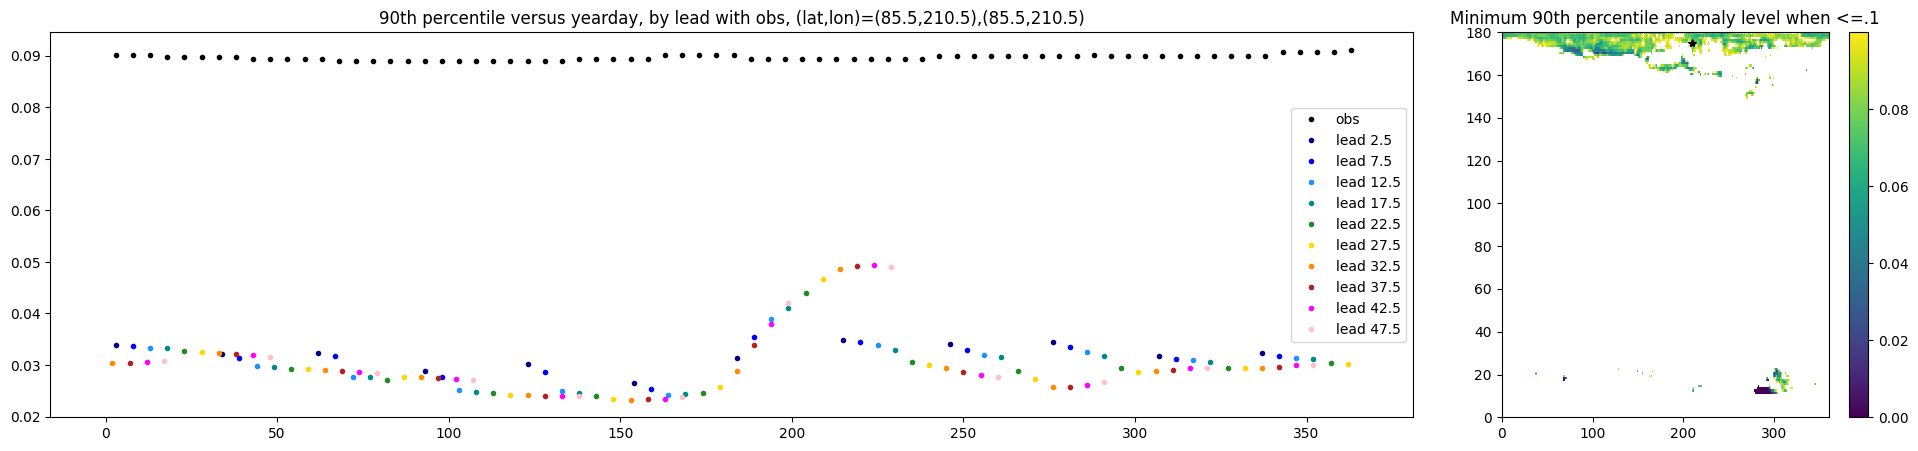

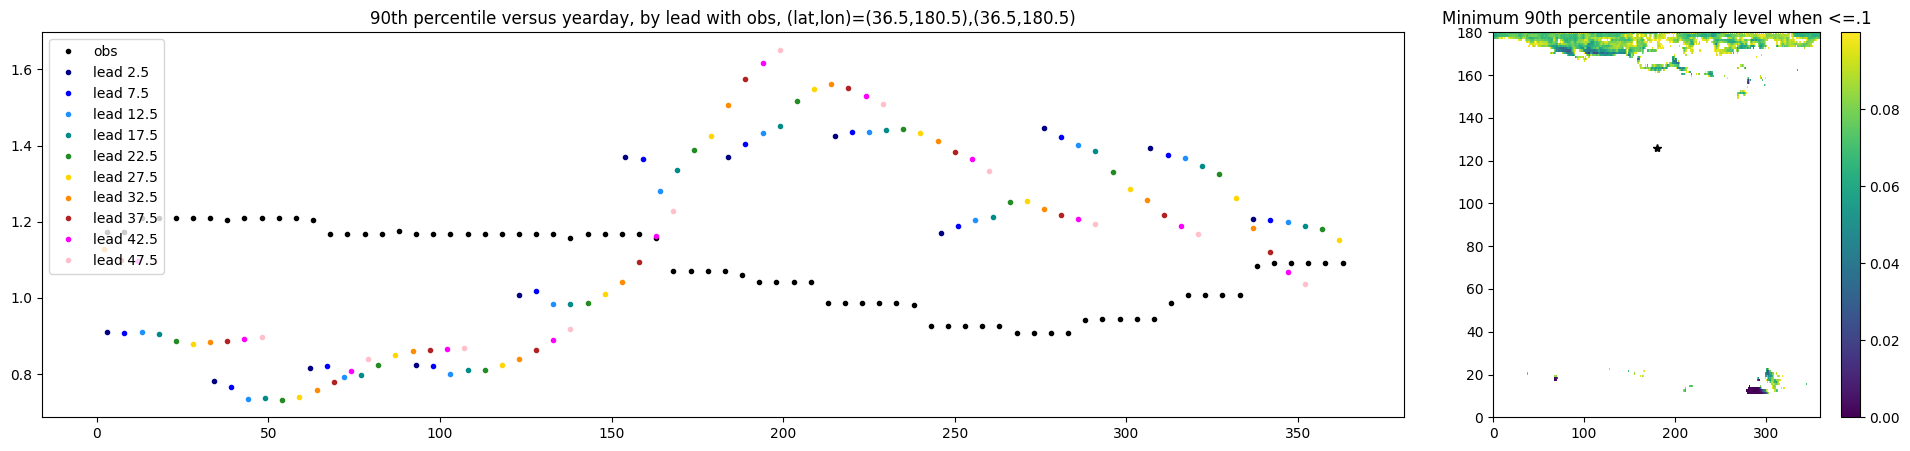

In [64]:
for ilon, ilat in [(125,173),(80,177),(210,175),(180,126)]:
    cols=['navy','blue','dodgerblue','darkcyan','forestgreen','gold','darkorange','firebrick','fuchsia','pink']
    fig,ax=plt.subplots(1,2,figsize=(24,5),gridspec_kw={'width_ratios':[1,.3],'wspace':.1})
    ax[0].plot(fQ.yd,fQ.qt1.isel(lat=ilat,lon=ilon),'k.',label='obs')
    leads=(fmq.leadtime.values+.5)*5
    for il in range(0,10):
        test=fmq.isel(leadtime=il,lat=ilat-120,lon=ilon)
        ilead=leads[il]
        ts=np.array([yd365(cftime.DatetimeNoLeap(2021,mm,1)+dt.timedelta(days=ilead)) for mm in range(1,13)])
        ax[0].plot(ts,test.qt1,'.',color=cols[il],label=f"lead {ilead}")
    ax[0].legend()
    ax[0].set_title(f'90th percentile versus yearday, by lead with obs, (lat,lon)=({fQ.lat.values[ilat]},{fQ.lon.values[ilon]}),({fmq.lat.values[ilat-120]},{fmq.lon.values[ilon]})')
    
    ax[1].set_title('Minimum 90th percentile anomaly level when <=.1')
    m=ax[1].pcolormesh(np.ma.masked_where(y>.1,y))
    ax[1].plot(ilon,ilat,'k*')
    fig.colorbar(m,ax=ax[1])

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(12,4))

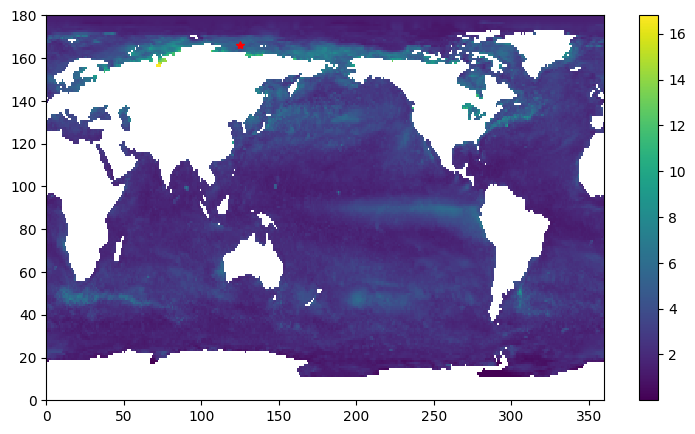

In [17]:
fig,ax=plt.subplots(1,1,figsize=(9,5))
m=ax.pcolormesh(ff.sst_an.max('time'))
fig.colorbar(m)
ax.plot(ilon,ilat,'r*')

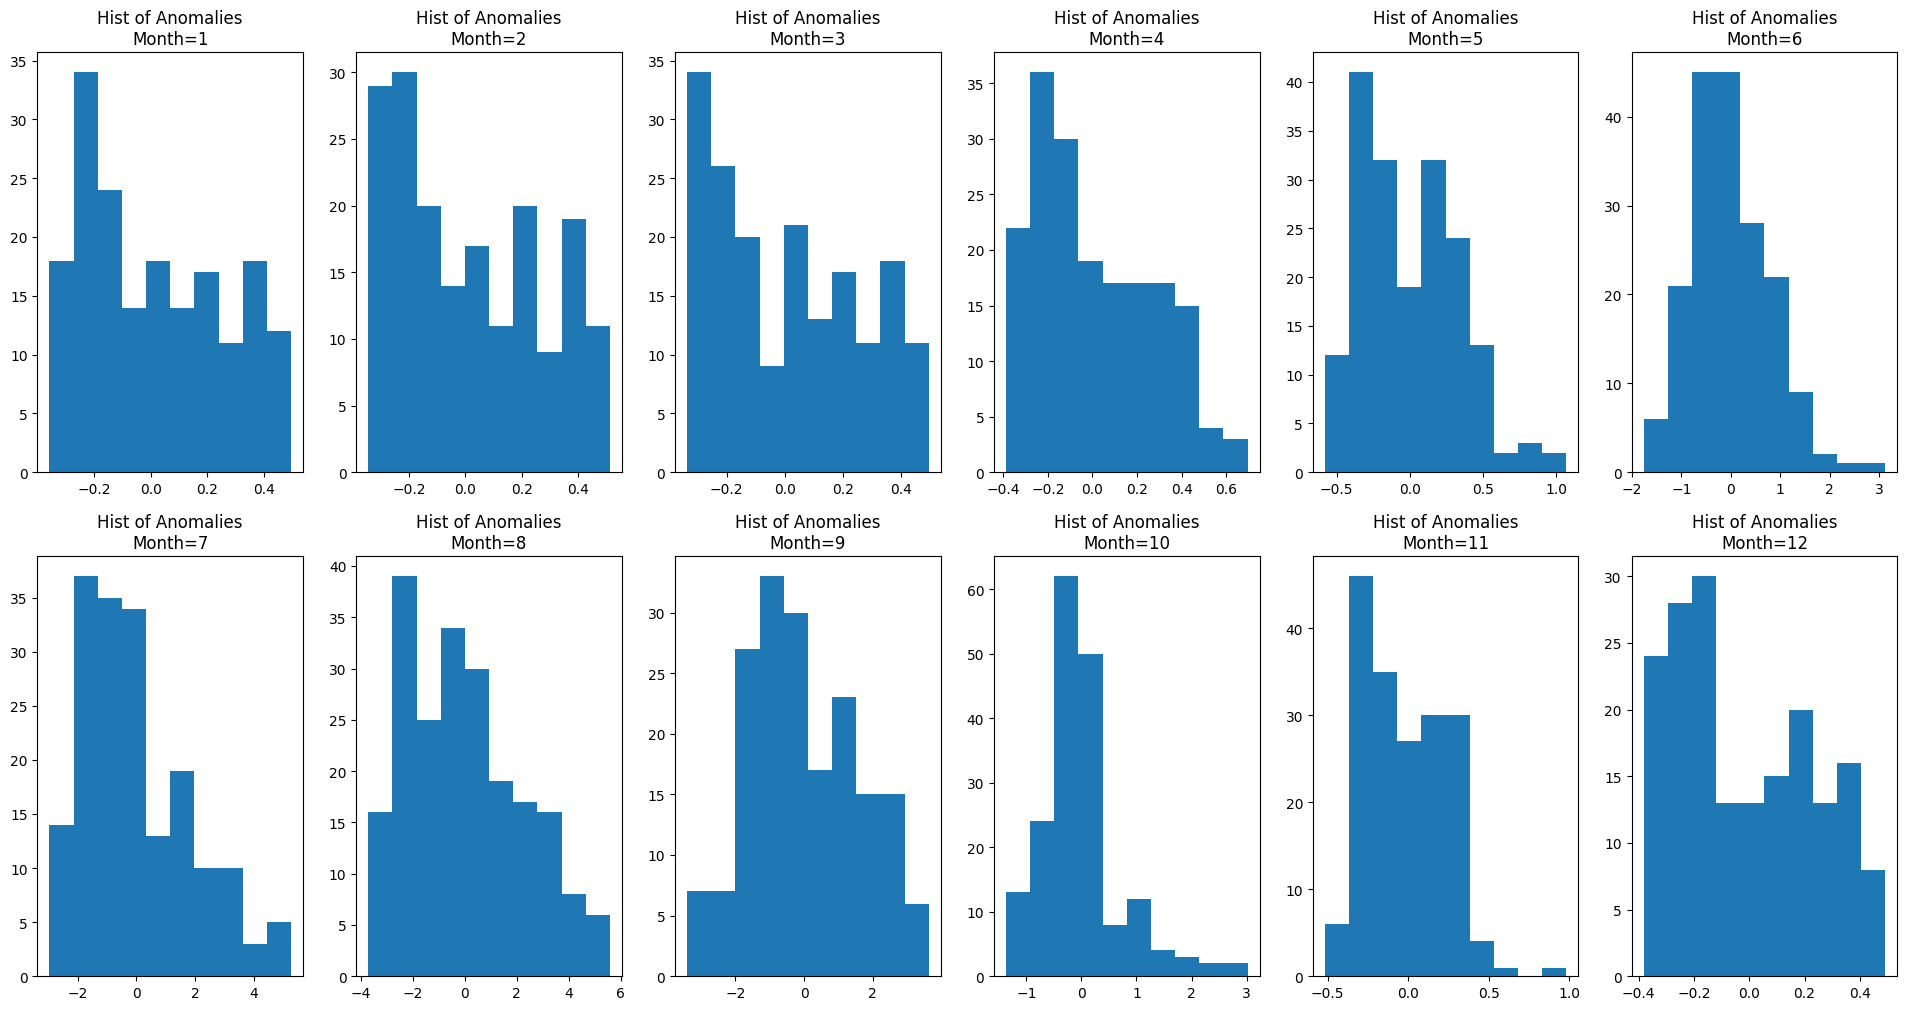

In [21]:
fig,ax=plt.subplots(2,6,figsize=(24,12))
ax=ax.flatten()
mon=np.array([el.month for el in ff.time.values])
for im in range(0,12):
    ax[im].hist(ff.sst_an.isel(time=(mon==im+1),lat=ilat,lon=ilon))
    ax[im].set_title(f'Hist of Anomalies\nMonth={im+1}')